# S2DR4 Super-Resolution — Khartoum, Sudan

This notebook super-resolves Sentinel-2 imagery from **10m to 1m/pixel** using Gamma Earth's S2DR4 model.

**Before running:** Go to `Runtime → Change runtime type → T4 GPU`

### Output Products (1m resolution, 4×4 km area):
| File | Description |
|------|-------------|
| `_MS.tif` | 10-band multispectral (B2,B3,B4,B5,B6,B7,B8,B8A,B11,B12) |
| `_TCI.tif` | True color RGB |
| `_NDVI.tif` | Vegetation index |
| `_IRP.tif` | Infrared pseudo-color |

## 1. Mount Google Drive, Verify GPU & Install S2DR4

In [3]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Link output to your Google Drive folder
import os
DRIVE_DIR = '/content/drive/MyDrive/Gamma Earth S2DR4'
OUTPUT_DIR = os.path.join(DRIVE_DIR, 'output')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Symlink so S2DR4 writes directly to your Drive
os.makedirs('/content/output', exist_ok=True)
!ln -sfn "{OUTPUT_DIR}" /content/output

print(f"Output will be saved to: {DRIVE_DIR}/output")

# Verify T4 GPU is available
!echo ""
!nvidia-smi --query-gpu=name,memory.total --format=csv,noheader

# Install S2DR4
!pip -q install https://storage.googleapis.com/0x7ff601307fa5/s2dr4-20260126.1-cp312-cp312-linux_x86_64.whl

Mounted at /content/drive
Output will be saved to: /content/drive/MyDrive/Gamma Earth S2DR4/output

Tesla T4, 15360 MiB
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 40.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.2/89.2 kB 6.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.3/254.3 kB 18.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.7/75.7 kB 8.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 47.5 MB/s eta 0:00:

## 2. Configure Location & Date

Edit the coordinates and date below for your area of interest.

In [4]:
# ──── CONFIGURATION ────────────────────────────────────────
# Khartoum, Sudan — center of your existing 10m data
# Format: (Longitude, Latitude) — NOTE: X, Y order!
LONLAT = (118.86, 28.989)

# Target date (S2DR4 picks the closest available Sentinel-2 scene)
# Archive available from 2018-01-01 onward
# Check availability: https://browser.dataspace.copernicus.eu
DATE = '2024-12-04'
# ──────────────────────────────────────────────────────────

print(f"Location : Quzhou, China")
print(f"Lon/Lat  : {LONLAT}")
print(f"Date     : {DATE}")
print(f"Area     : 4 × 4 km")
print(f"Output   : 1 m/px (10× super-resolution)")

Location : Quzhou, China
Lon/Lat  : (118.86, 28.989)
Date     : 2024-12-04
Area     : 4 × 4 km
Output   : 1 m/px (10× super-resolution)


## 3. Run Super-Resolution Inference

Preprocessing T50RPT-33e3bdb52-20241128 (5)  done.
Preprocessing T50RPT-33e3bdb52-20241201 (8) ...x...x...... done.
 done.
Preprocessing T50RPT-33e3bdb52-20241126 (45) xx.xxxx..xx... done.
Preprocessing T50RPT-33e3bdb52-20241123 (48) .............. done.
Preprocessing T50RPT-33e3bdb52-20241111 (17) ..xx......x... done.


Fetching model: 100%|██████████| 841M/841M [00:10<00:00, 77.8MiB/s]


Processing T50RPT-33e3bdb52-20241201 . done.
Postprocessing T50RPT-33e3bdb52-20241201 .....,..,.. done.

Find results at the following path: /content/output
Click the link below for preview:

https://gamayos.github.io/gamma-earth-api/s2dr4-sd-demo-01.html?ds=CN-T50RPT-33e3bdb52-20241201#15/28.9891/118.8600



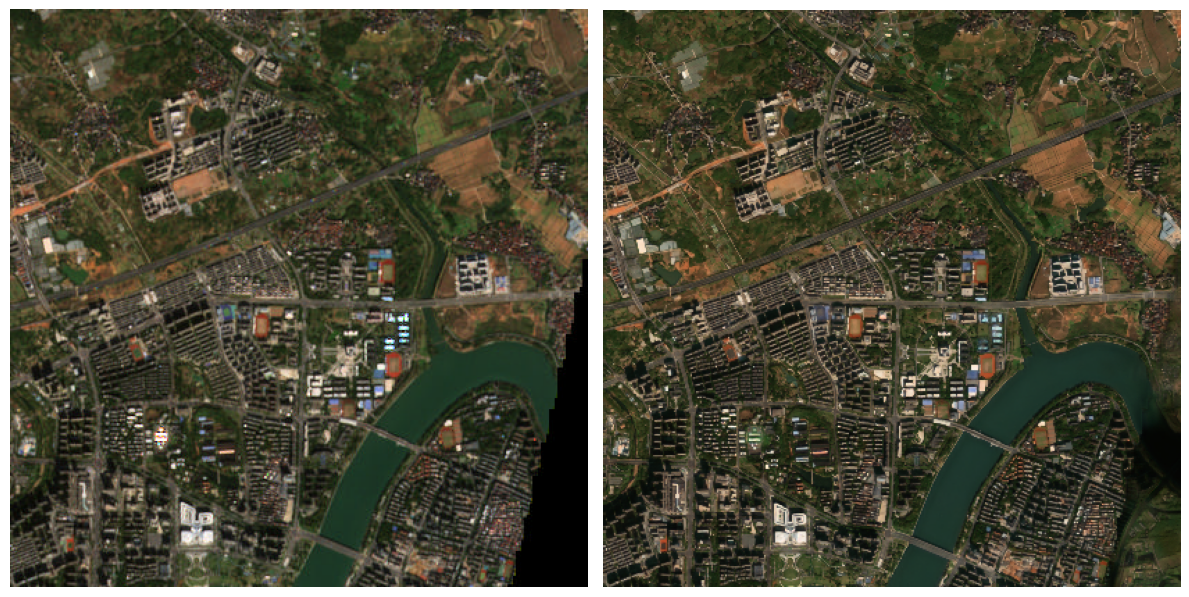

In [5]:
import s2dr4.inferutils

s2dr4.inferutils.test(LONLAT, DATE)

## 4. List & Preview Results

In [6]:
import os
import rasterio
import numpy as np
import matplotlib.pyplot as plt

OUTPUT_DIR = '/content/output'
tif_files = sorted(f for f in os.listdir(OUTPUT_DIR) if f.endswith('.tif'))

print("Generated files (saved to Google Drive):")
print("-" * 60)
for f in tif_files:
    fpath = os.path.join(OUTPUT_DIR, f)
    size_mb = os.path.getsize(fpath) / (1024 * 1024)
    with rasterio.open(fpath) as ds:
        print(f"  {f}")
        print(f"    {ds.width}x{ds.height} px, {ds.count} bands, {size_mb:.1f} MB")

print()
print(f"Results saved to: /content/drive/MyDrive/Gamma Earth S2DR4/output")

Generated files (saved to Google Drive):
------------------------------------------------------------

Results saved to: /content/drive/MyDrive/Gamma Earth S2DR4/output


In [7]:
# Show True Color preview of the super-resolved result
tci_files = [f for f in tif_files if '_TCI' in f]

if tci_files:
    with rasterio.open(os.path.join(OUTPUT_DIR, tci_files[0])) as ds:
        img = ds.read([1, 2, 3])  # RGB
        img = np.moveaxis(img, 0, -1)  # (H, W, 3)
        # Normalize to 0-1 for display
        p2, p98 = np.nanpercentile(img, [2, 98])
        img = np.clip((img - p2) / (p98 - p2), 0, 1)

    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    ax.imshow(img)
    ax.set_title(f'Super-Resolved True Color (1m) — {tci_files[0]}', fontsize=12)
    ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("No TCI file found. Showing MS band 4,3,2 instead.")
    ms_files = [f for f in tif_files if '_MS' in f]
    if ms_files:
        with rasterio.open(os.path.join(OUTPUT_DIR, ms_files[0])) as ds:
            img = ds.read([3, 2, 1])  # B4,B3,B2
            img = np.moveaxis(img, 0, -1)
            p2, p98 = np.nanpercentile(img, [2, 98])
            img = np.clip((img - p2) / (p98 - p2), 0, 1)
        fig, ax = plt.subplots(1, 1, figsize=(10, 10))
        ax.imshow(img)
        ax.set_title('Super-Resolved RGB from MS bands (1m)', fontsize=12)
        ax.axis('off')
        plt.tight_layout()
        plt.show()

No TCI file found. Showing MS band 4,3,2 instead.


## 5. Download Results

Results are **already saved to your Google Drive** at:
```
Google Drive/Gamma Earth S2DR4/output/
```
They will sync automatically to your PC if you have Google Drive desktop installed.

Run the cell below **only** if you want a direct browser download as well.

In [8]:
import shutil
from google.colab import files

# Zip all output TIFs
zip_name = 'S2DR4_Khartoum_1m'
shutil.make_archive(f'/content/{zip_name}', 'zip', OUTPUT_DIR)

zip_path = f'/content/{zip_name}.zip'
size_mb = os.path.getsize(zip_path) / (1024 * 1024)
print(f"Download: {zip_name}.zip ({size_mb:.1f} MB)")

# Trigger browser download
files.download(zip_path)

Download: S2DR4_Khartoum_1m.zip (249.7 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
*Powered by [Gamma Earth S2DR4](https://medium.com/@ya_71389/c71a601a2253) — Sentinel-2 Deep Resolution 4.0*